In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns
from sklearn.model_selection import train_test_split


In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head()
titanic.info()
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [5]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
# missing data

from sklearn.impute import SimpleImputer 

imp_median = SimpleImputer(strategy ="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])                          # AGE = NUMERICAL 

imp_freq = SimpleImputer(strategy ="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])                   # EMBARKED =  STRING TYPE []S,S,C,S] 



In [7]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
# encode

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"]) 
titanic["embarked"] = le.fit_transform(titanic["embarked"]) 

In [9]:
X = titanic[features]
y = titanic[target]

In [10]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state=42
)

In [12]:
X_train.head()

,pclass,sex,fare,embarked,age
445,1,1,81.8583,2,4.0
650,3,1,7.8958,2,28.0
172,3,0,11.1333,2,1.0
450,2,1,27.7500,2,36.0
314,2,1,26.2500,2,43.0


In [13]:
# Decision Tree Model - no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.7649253731343284


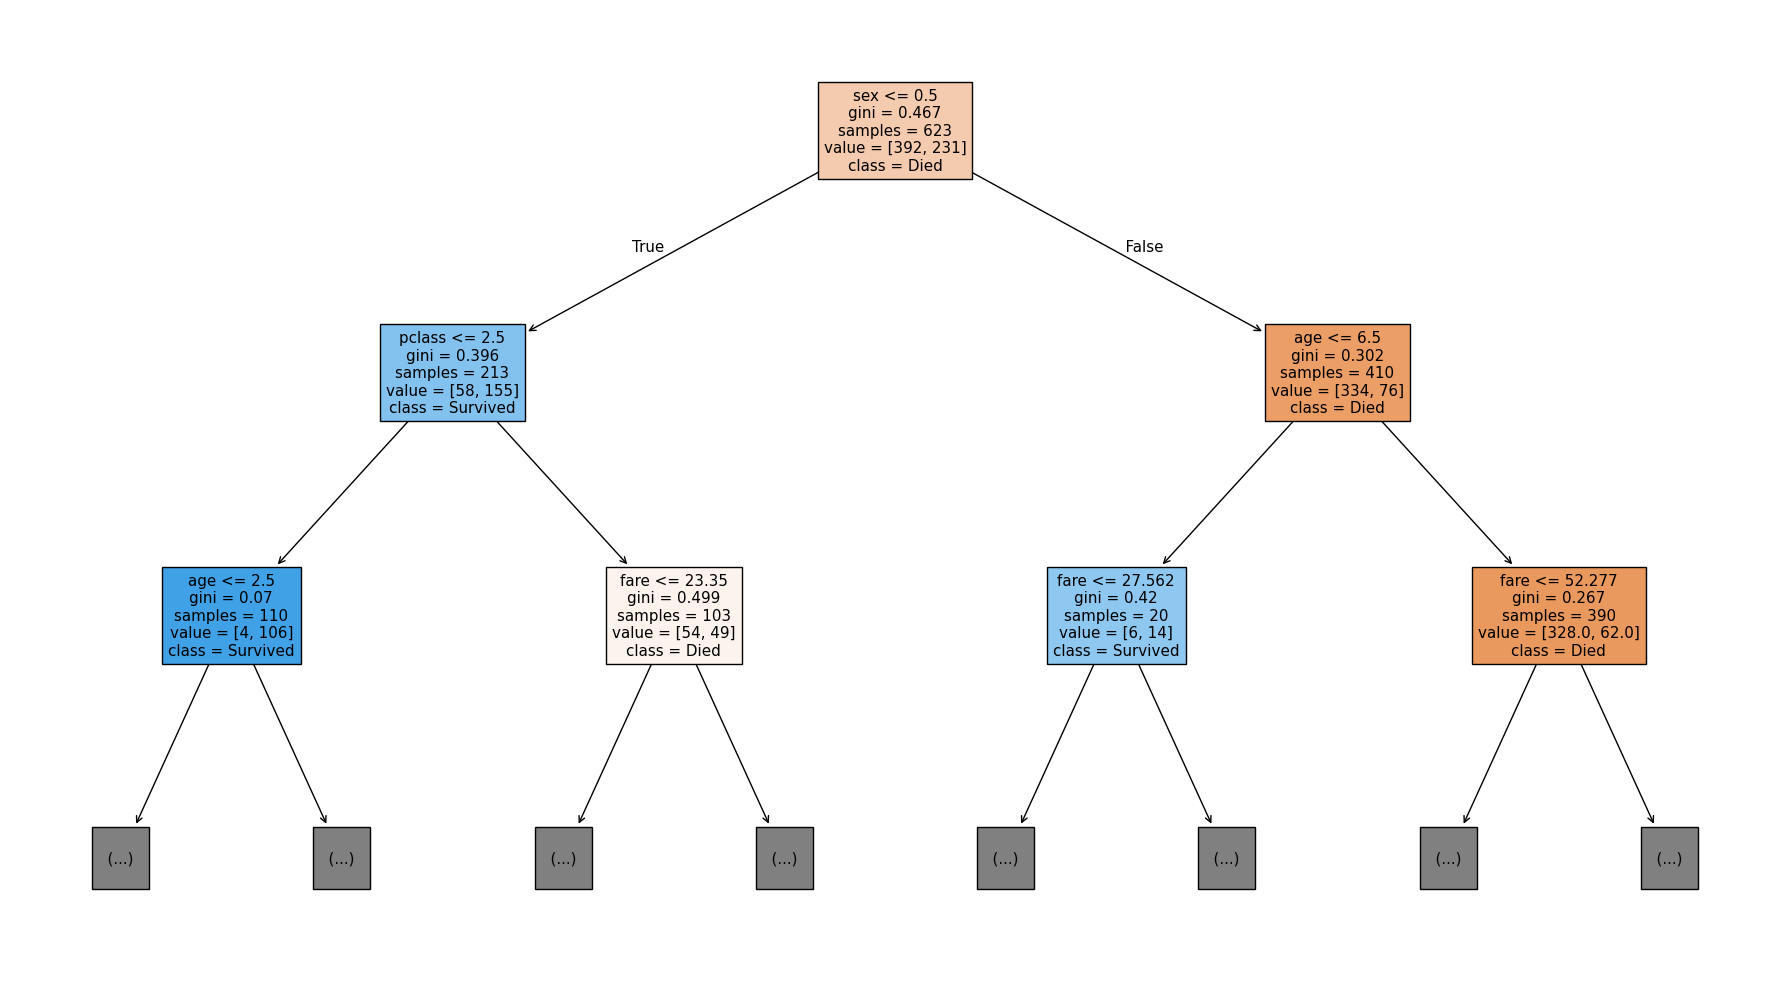

In [15]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()

# decision tree with pre - pruning 

for depths =2,accuracy=0.7723880597014925


<Figure size 640x480 with 0 Axes>

for depths =3,accuracy=0.8059701492537313


<Figure size 640x480 with 0 Axes>

for depths =4,accuracy=0.8246268656716418


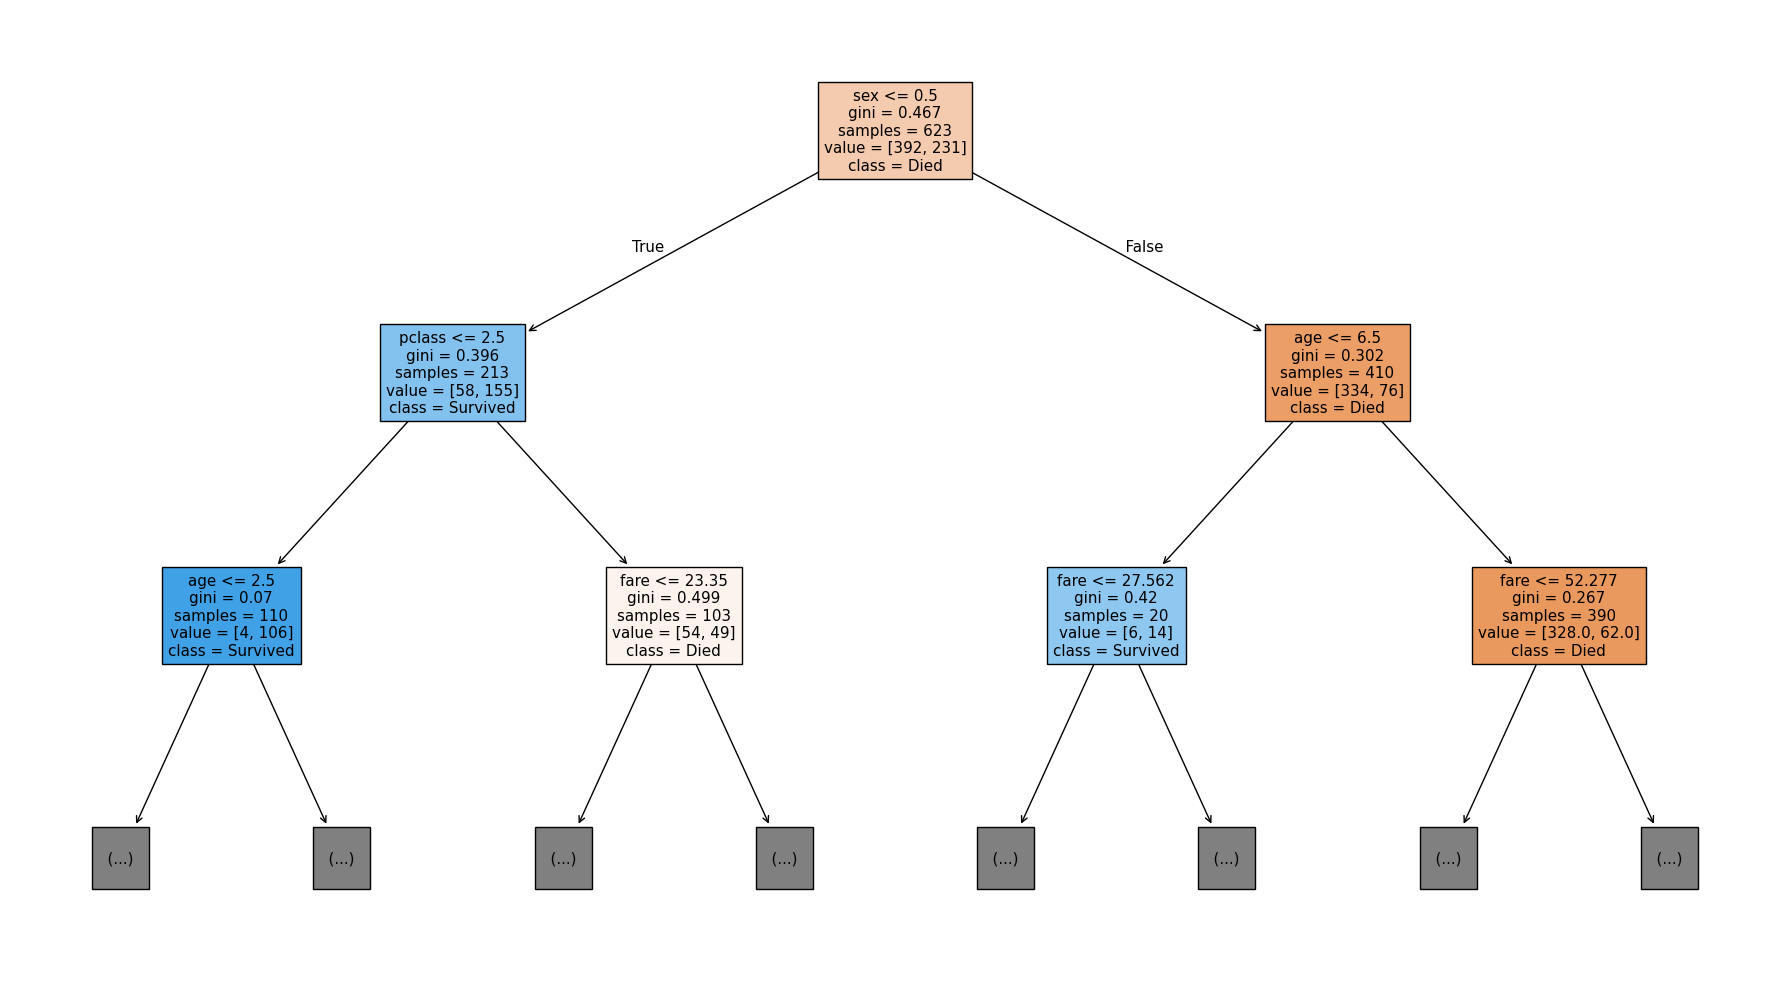

for depths =5,accuracy=0.7985074626865671


<Figure size 640x480 with 0 Axes>

for depths =6,accuracy=0.7873134328358209


<Figure size 640x480 with 0 Axes>

for depths =7,accuracy=0.7798507462686567


<Figure size 640x480 with 0 Axes>

for depths =8,accuracy=0.8022388059701493


<Figure size 640x480 with 0 Axes>

for depths =9,accuracy=0.7723880597014925


<Figure size 640x480 with 0 Axes>

In [25]:
max_depths = [2,3,4,5,6,7,8,9]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test)
    print(f"for depths ={depth},accuracy={acc}")

    if depth==4:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True,
            max_depth=2
    )
    plt.tight_layout()
    plt.show()

For split=2, accuracy=0.8246268656716418
For split=3, accuracy=0.8246268656716418
For split=4, accuracy=0.8246268656716418
For split=5, accuracy=0.8246268656716418


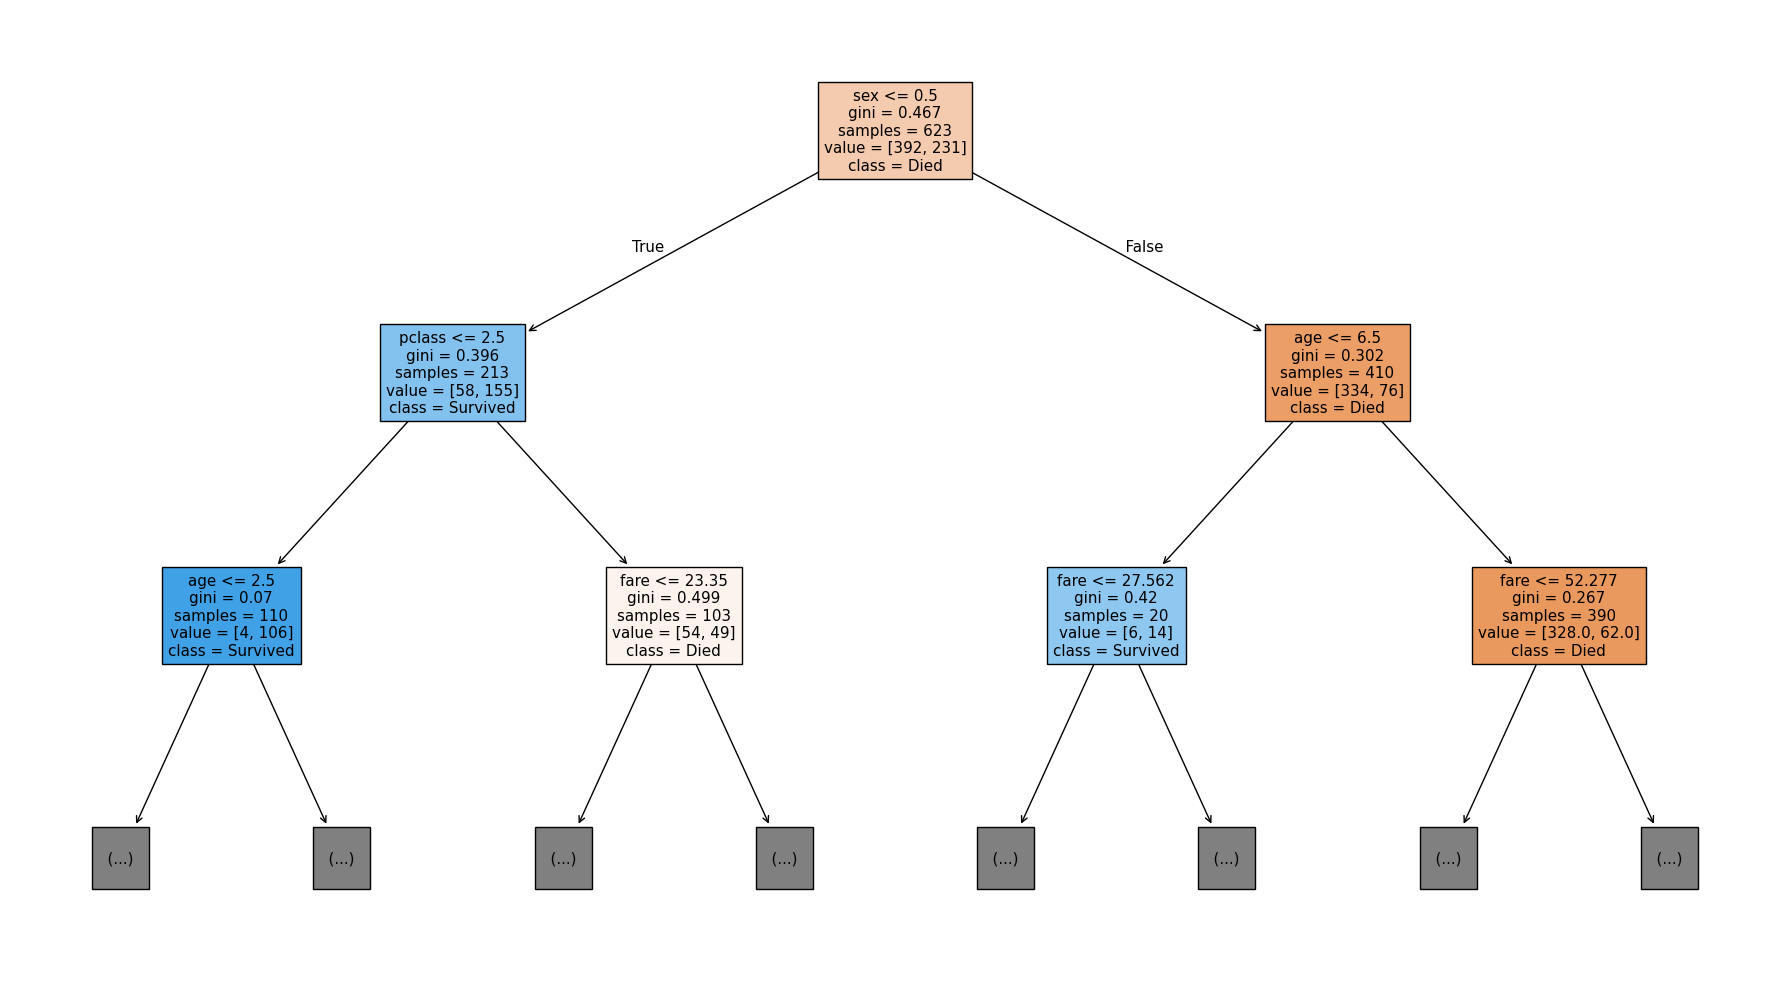

For split=6, accuracy=0.8246268656716418
For split=7, accuracy=0.8246268656716418
For split=8, accuracy=0.8246268656716418
For split=9, accuracy=0.8246268656716418


In [32]:
min_samples_splits = [2,3,4,5,6,7,8,9]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"For split={split}, accuracy={acc}")

    if split == 5:   # koi value jo list me ho
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died","Survived"],
            filled=True,
            max_depth=2
        )
        plt.tight_layout()
        plt.show()

# Decision Trees with Post pruning

In [36]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [44]:
# now abb. hum Best ccp_alphas  dundege..........

# train our model for all ALPHAS...

tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha =alpha)
    model.fit(X_train,y_train)
    acc =model.score(X_test,y_test)

    tree.append((model,acc))


In [49]:
best_acc = 0
best_alpha = 0

for model,alpha in tree:
    curr_acc =model.score(X_test,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_acc = curr_acc
        best_alpha = alpha

In [50]:
best_alpha

0.8208955223880597

In [51]:
best_acc

0.8208955223880597

In [61]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=4)
best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


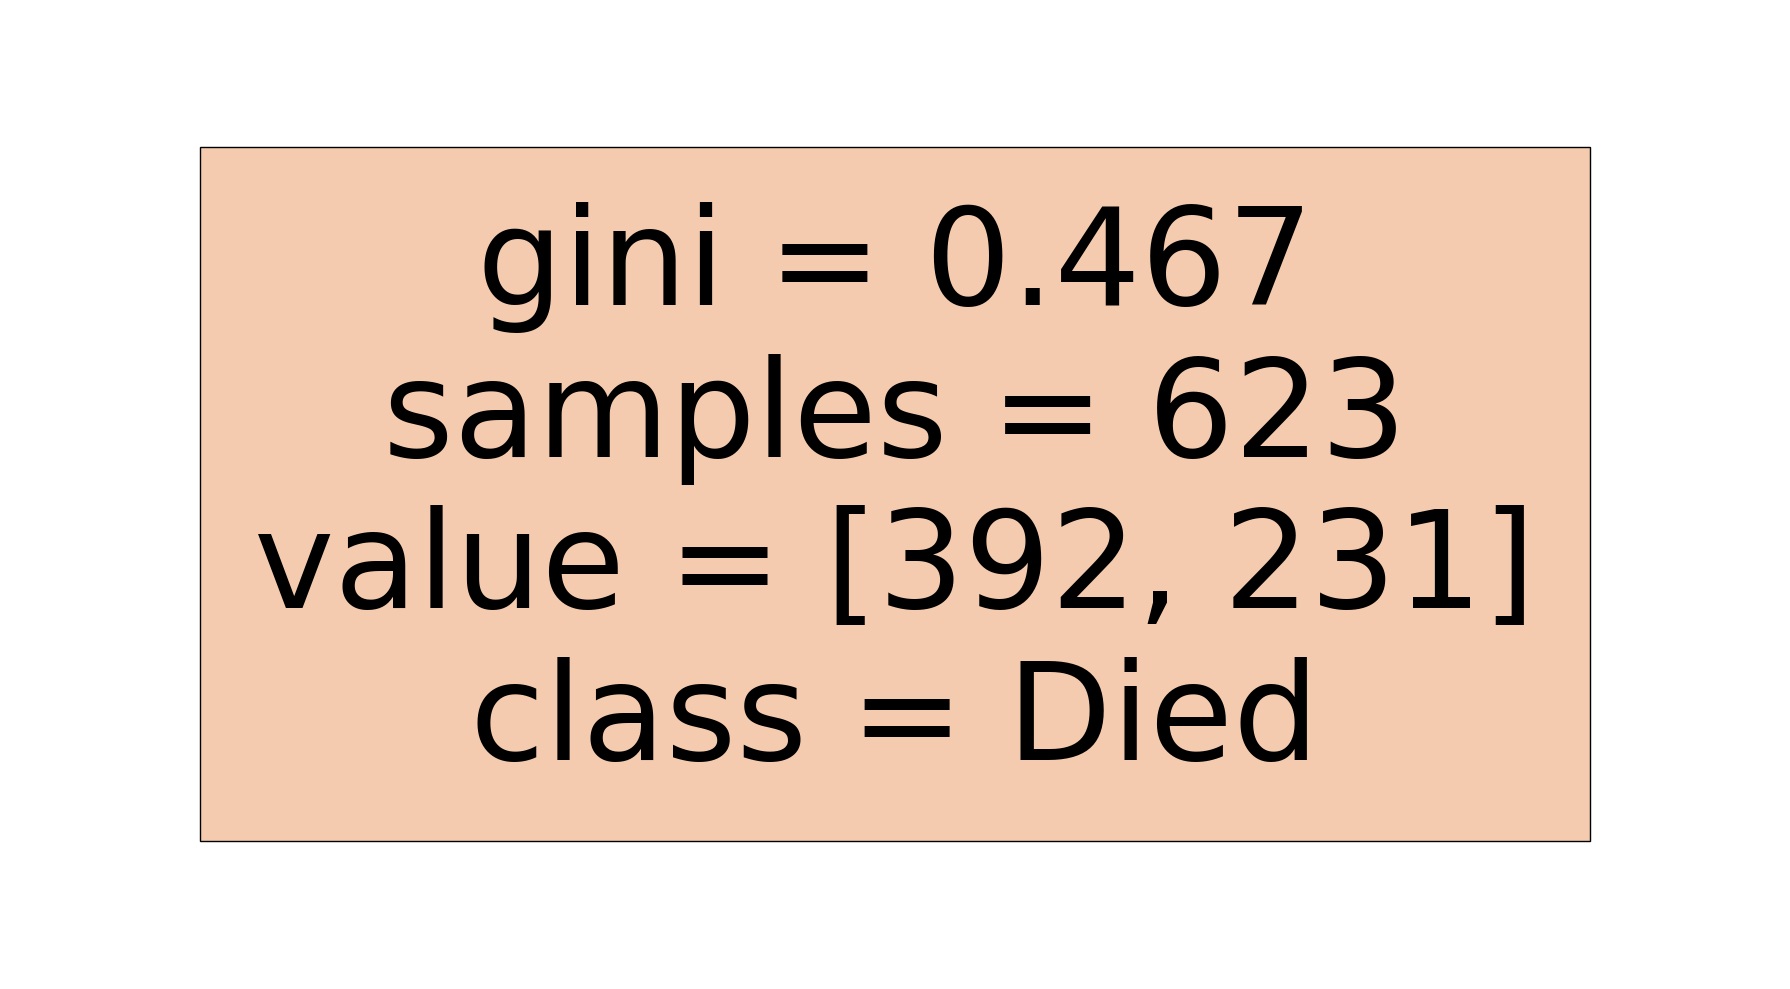

In [62]:
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)
        
plt.tight_layout()
plt.show()

In [63]:
print(best_model.score(X_test, y_test))

0.585820895522388
